# macrotoolkit from a notebook: the lw_sv output layer, no YAML, no CLI

This notebook is the S6 WP1 acceptance example: the whole existing
workflow -- spec construction, run handles, results objects, inline figures,
parameter tables, the self-contained report -- driven from Python through
`macrotoolkit.api`. It runs the **archived reference run**
(`runs-archive/a00958509083`, the S5 pre-COVID `lw_sv` SV run, draw-thinned
x10 as a development fixture) so it needs **no sampling**; the same handle
API applies to a run you estimate with `mtk.fit(...)`.

The canonical import is `from macrotoolkit import api as mtk`.

In [1]:
from pathlib import Path
import shutil, tempfile
%matplotlib inline
import matplotlib.pyplot as plt

from macrotoolkit import api as mtk

from macrotoolkit.run import REPO_ROOT as REPO  # the checkout this package is installed from
ARCHIVE = REPO / "runs-archive" / "a00958509083"
print("archived run:", ARCHIVE)

archived run: /home/user/stan-mcm/runs-archive/a00958509083


/root/.local/share/uv/tools/pytest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. A spec is a Pydantic object -- and it hashes exactly like the YAML

`mtk.spec(...)` returns a validated `RunSpec`. Built with the same content
as `examples/us_lw_sv/spec_sv.yaml` it serializes to the same estimation
YAML, so it would land on the **same run hash** (the run identity covers
the canonical spec minus report/QC options, the data bytes, the rendered
Stan program and the CmdStan version). `tests/test_api.py` pins this.

In [2]:
spec = mtk.spec(
    "lw_sv",
    data={"file": "data/us_quarterly.csv", "date_column": "date",
          "mapping": {"y": "lgdp100", "pi": "core_pce_ann", "r": "real_rate"}},
    options={"sv_shocks": ["is", "pc"]},
    sampler={"chains": 4, "warmup": 1500, "sampling": 1500, "adapt_delta": 0.95,
             "max_treedepth": 12, "seed": 20260813},
)
yaml_spec = mtk.load_spec(str(REPO / "examples" / "us_lw_sv" / "spec_sv.yaml"))
print("identical estimation identity:", spec.to_estimation_yaml() == yaml_spec.to_estimation_yaml())
print(spec.to_estimation_yaml())

identical estimation identity: True
data:
  date_column: date
  file: data/us_quarterly.csv
  mapping:
    pi: core_pce_ann
    r: real_rate
    y: lgdp100
  sample:
    end: null
    start: null
model:
  family: lw_sv
  options:
    estimate_c: false
    family: lw_sv
    sv_shocks:
    - is
    - pc
priors: {}
sampler:
  adapt_delta: 0.95
  chains: 4
  max_treedepth: 12
  sampling: 1500
  seed: 20260813
  warmup: 1500



To estimate it you would call `run = mtk.fit(spec, base_dir=REPO / "examples/us_lw_sv")`
(or pass a pandas DataFrame as the second argument). Here we open the
archived run instead. A working copy is used so the notebook never writes
into the tracked fixture; `outputs.yaml` sits outside the run identity, so
thinning the smoother draws further for speed is a legitimate report-option
refresh.

In [3]:
work = Path(tempfile.mkdtemp(prefix="mtk_nb_")) / ARCHIVE.name
shutil.copytree(ARCHIVE, work)
import yaml
outputs = yaml.safe_load((work / "outputs.yaml").read_text())
outputs["smoother_draws"] = {"thin": 5}
outputs["prior_predictive_draws"] = 100
(work / "outputs.yaml").write_text(yaml.safe_dump(outputs, sort_keys=True))

run = mtk.load_run(work)
run

Run(a00958509083, family='lw_sv', verdict='PASS', dir='/tmp/mtk_nb_d6g7nqsa/a00958509083')

## 2. The run handle: hash, spec, diagnostics verdict, posterior

In [4]:
print("hash:", run.hash)
print("family:", run.family, "| sv_shocks:", run.spec.model.options.sv_shocks)
print("verdict:", run.verdict, "|", run.diagnostics["reasons"])
print("divergences:", run.diagnostics["divergences"], "| max R-hat:", round(run.diagnostics["rhat_max"], 4))
print("posterior dims:", dict(run.idata.posterior.sizes))

hash: a00958509083
family: lw_sv | sv_shocks: ['is', 'pc']
verdict: PASS | ['no divergences, treedepth hits, low E-BFMI, high R-hat, or low ESS detected']
divergences: 0 | max R-hat: 1.0045


posterior dims: {'chain': 4, 'draw': 150, 'nu_is_dim_0': 234, 'nu_pc_dim_0': 234, 'h_is_dim_0': 234, 'h_pc_dim_0': 234}


In [5]:
run.param_table().round(4)

,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
a1,1.2803,1.1496,1.4398,0.9999,585.6056,554.5228
a2,-0.3098,-0.4680,-0.1822,1.0008,581.7476,639.2365
a_r,-0.0460,-0.0857,-0.0163,1.0041,557.4445,580.4551
b_pi,0.6192,0.5124,0.7261,0.9994,619.7326,591.4488
b_y,0.0354,0.0113,0.0668,1.0059,565.0178,529.2409
h0_is_raw,-0.3646,-1.3618,0.6153,1.0033,564.8408,566.9035
h0_pc_raw,-0.8060,-1.6024,0.0775,1.0037,715.2427,634.9597
sigma_g,0.0664,0.0430,0.0980,1.0045,544.5643,487.0515
sigma_h_is,0.2539,0.1411,0.4233,1.0031,641.9130,687.8716


## 3. Results objects and inline figures

`run.results()` is the family's results object (`LWRun` for lw_sv);
`run.outputs()` exposes the family's declared output modules -- the same
declaration the HTML report renders -- as data objects and live matplotlib
Figures.

In [6]:
res = run.results()
outs = run.outputs()
print("output modules:", outs.names)
tcd = outs.compute("trend_cycle")
print("trend-cycle draws:", tcd.rstar.shape, "| dates", tcd.dates[0].date(), "->", tcd.dates[-1].date())

output modules: ('prior_predictive', 'trend_cycle', 'irf', 'fan', 'hd')


trend-cycle draws: (120, 234) | dates 1961-01-01 -> 2019-04-01


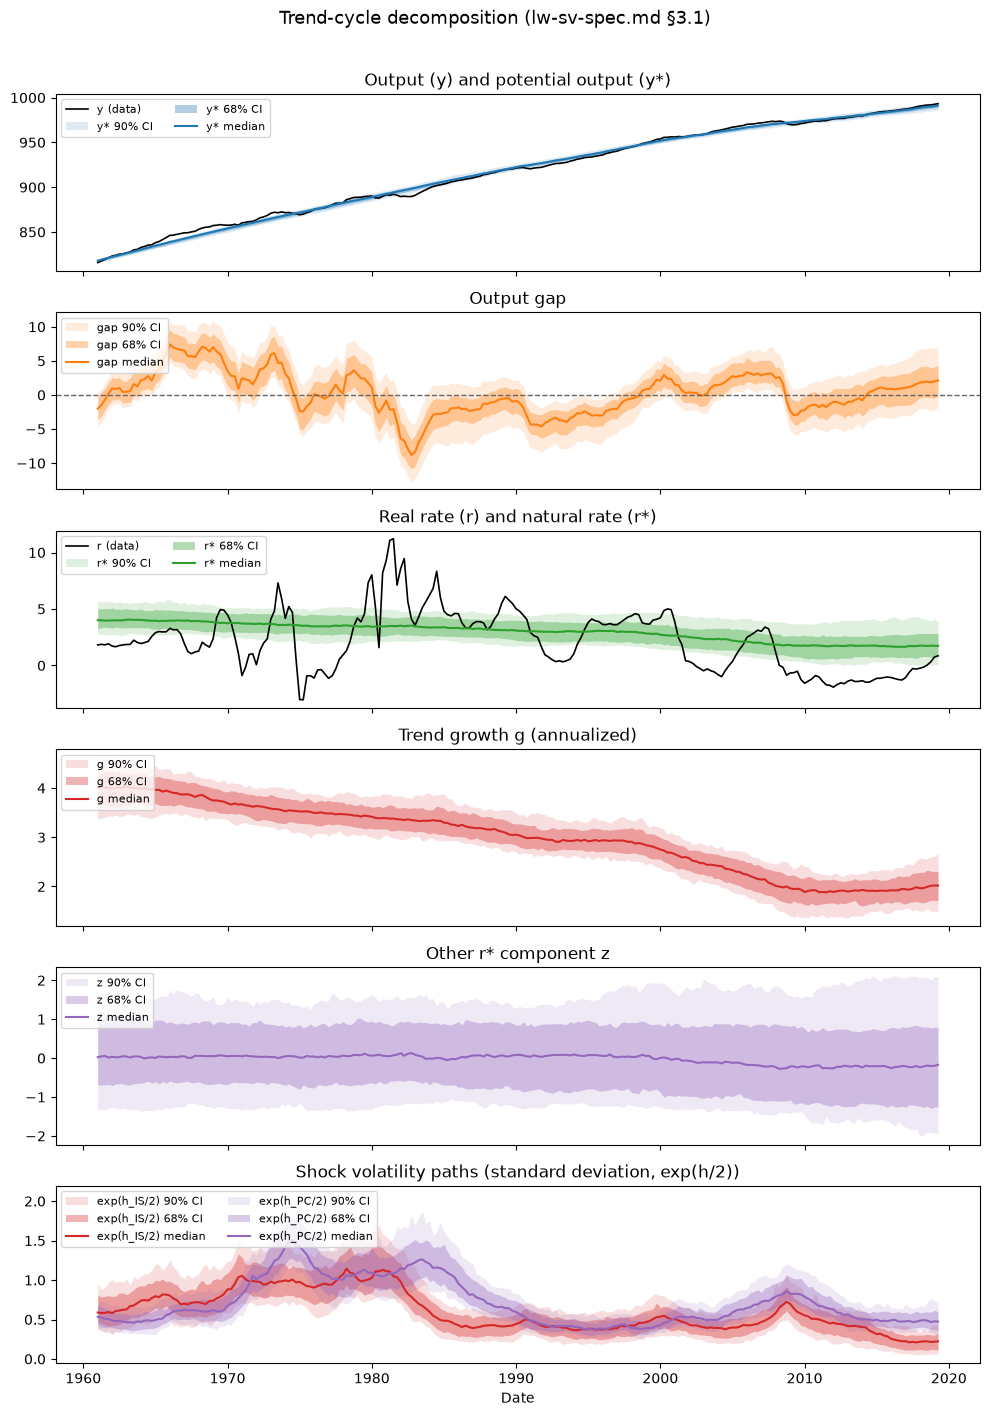

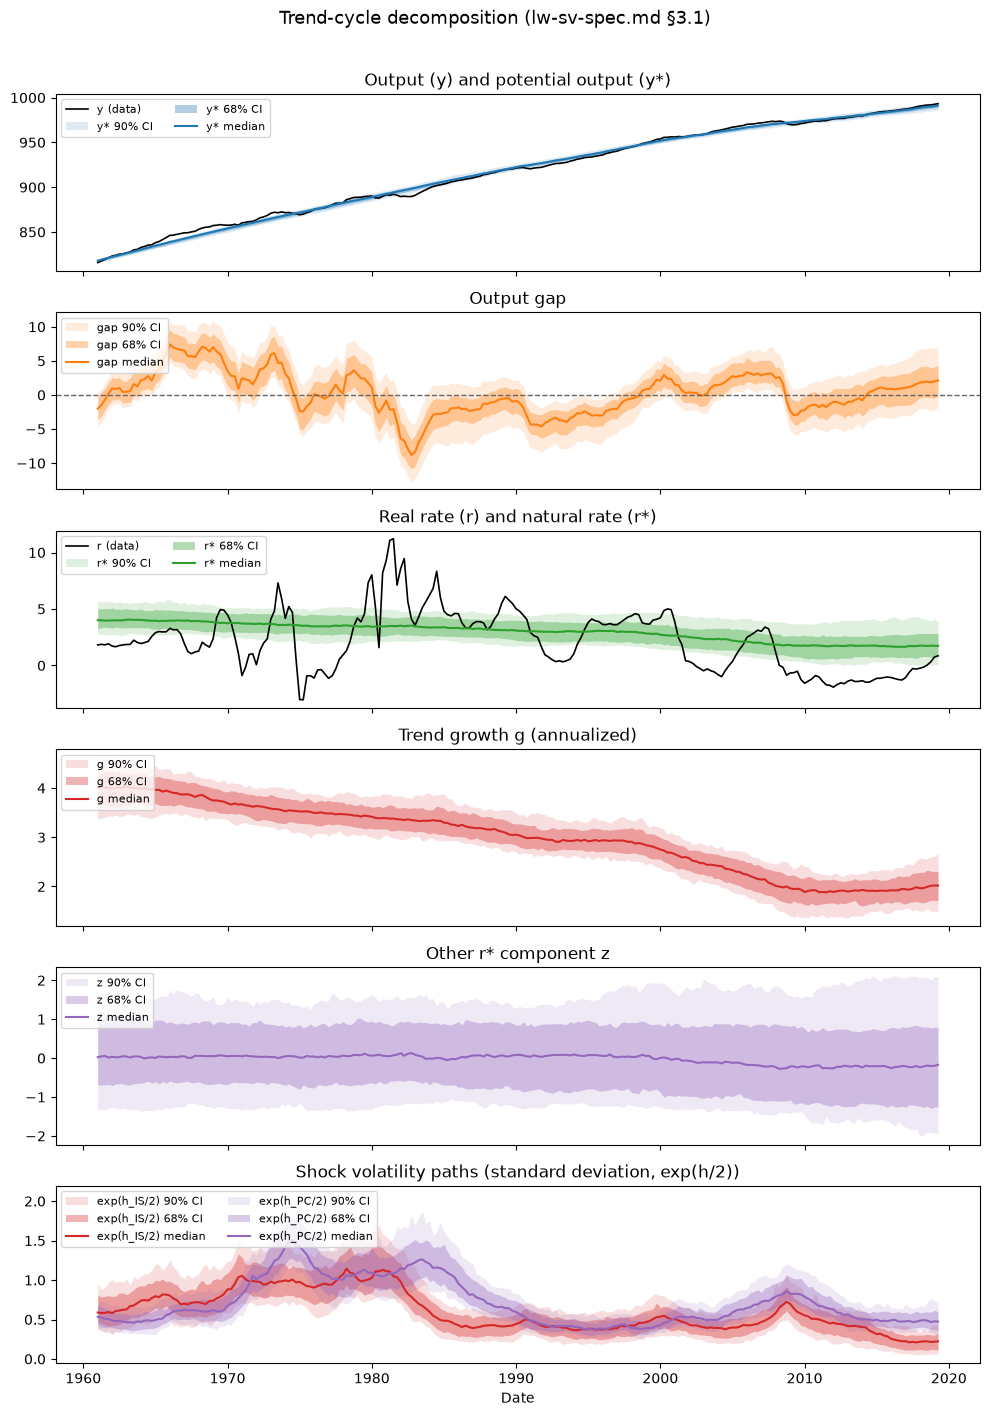

In [7]:
fig = outs.figure("trend_cycle")
fig

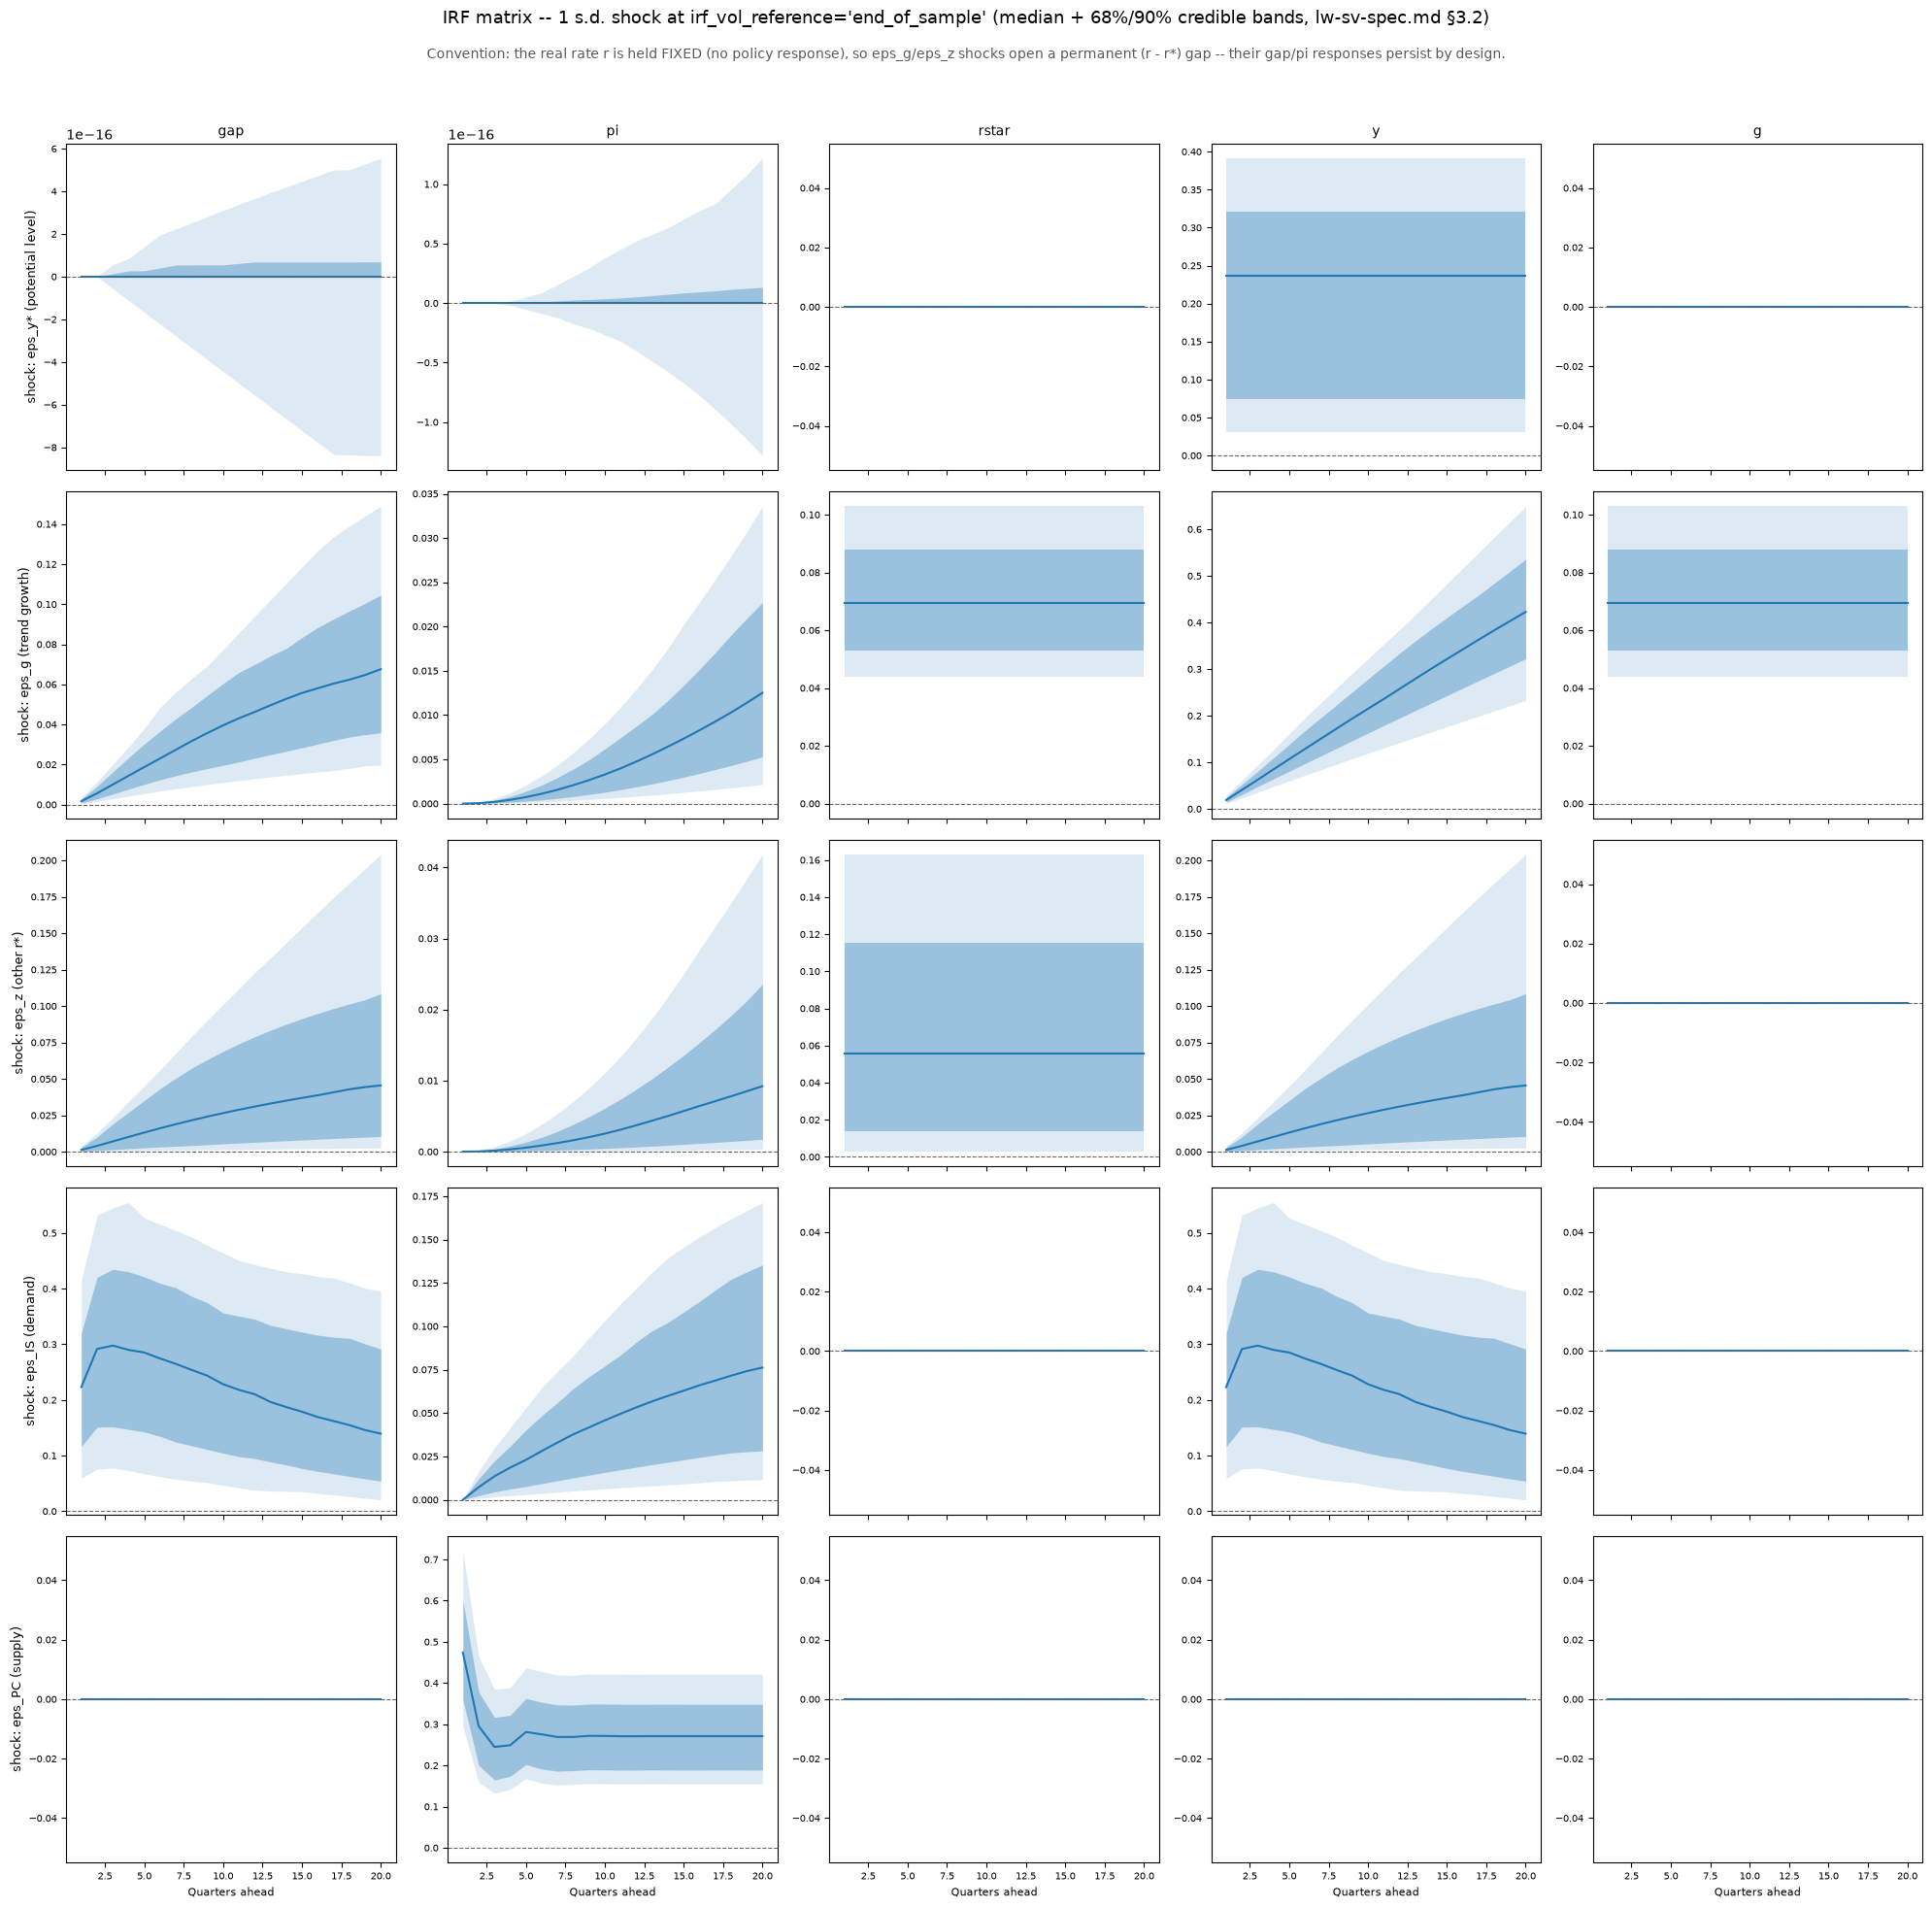

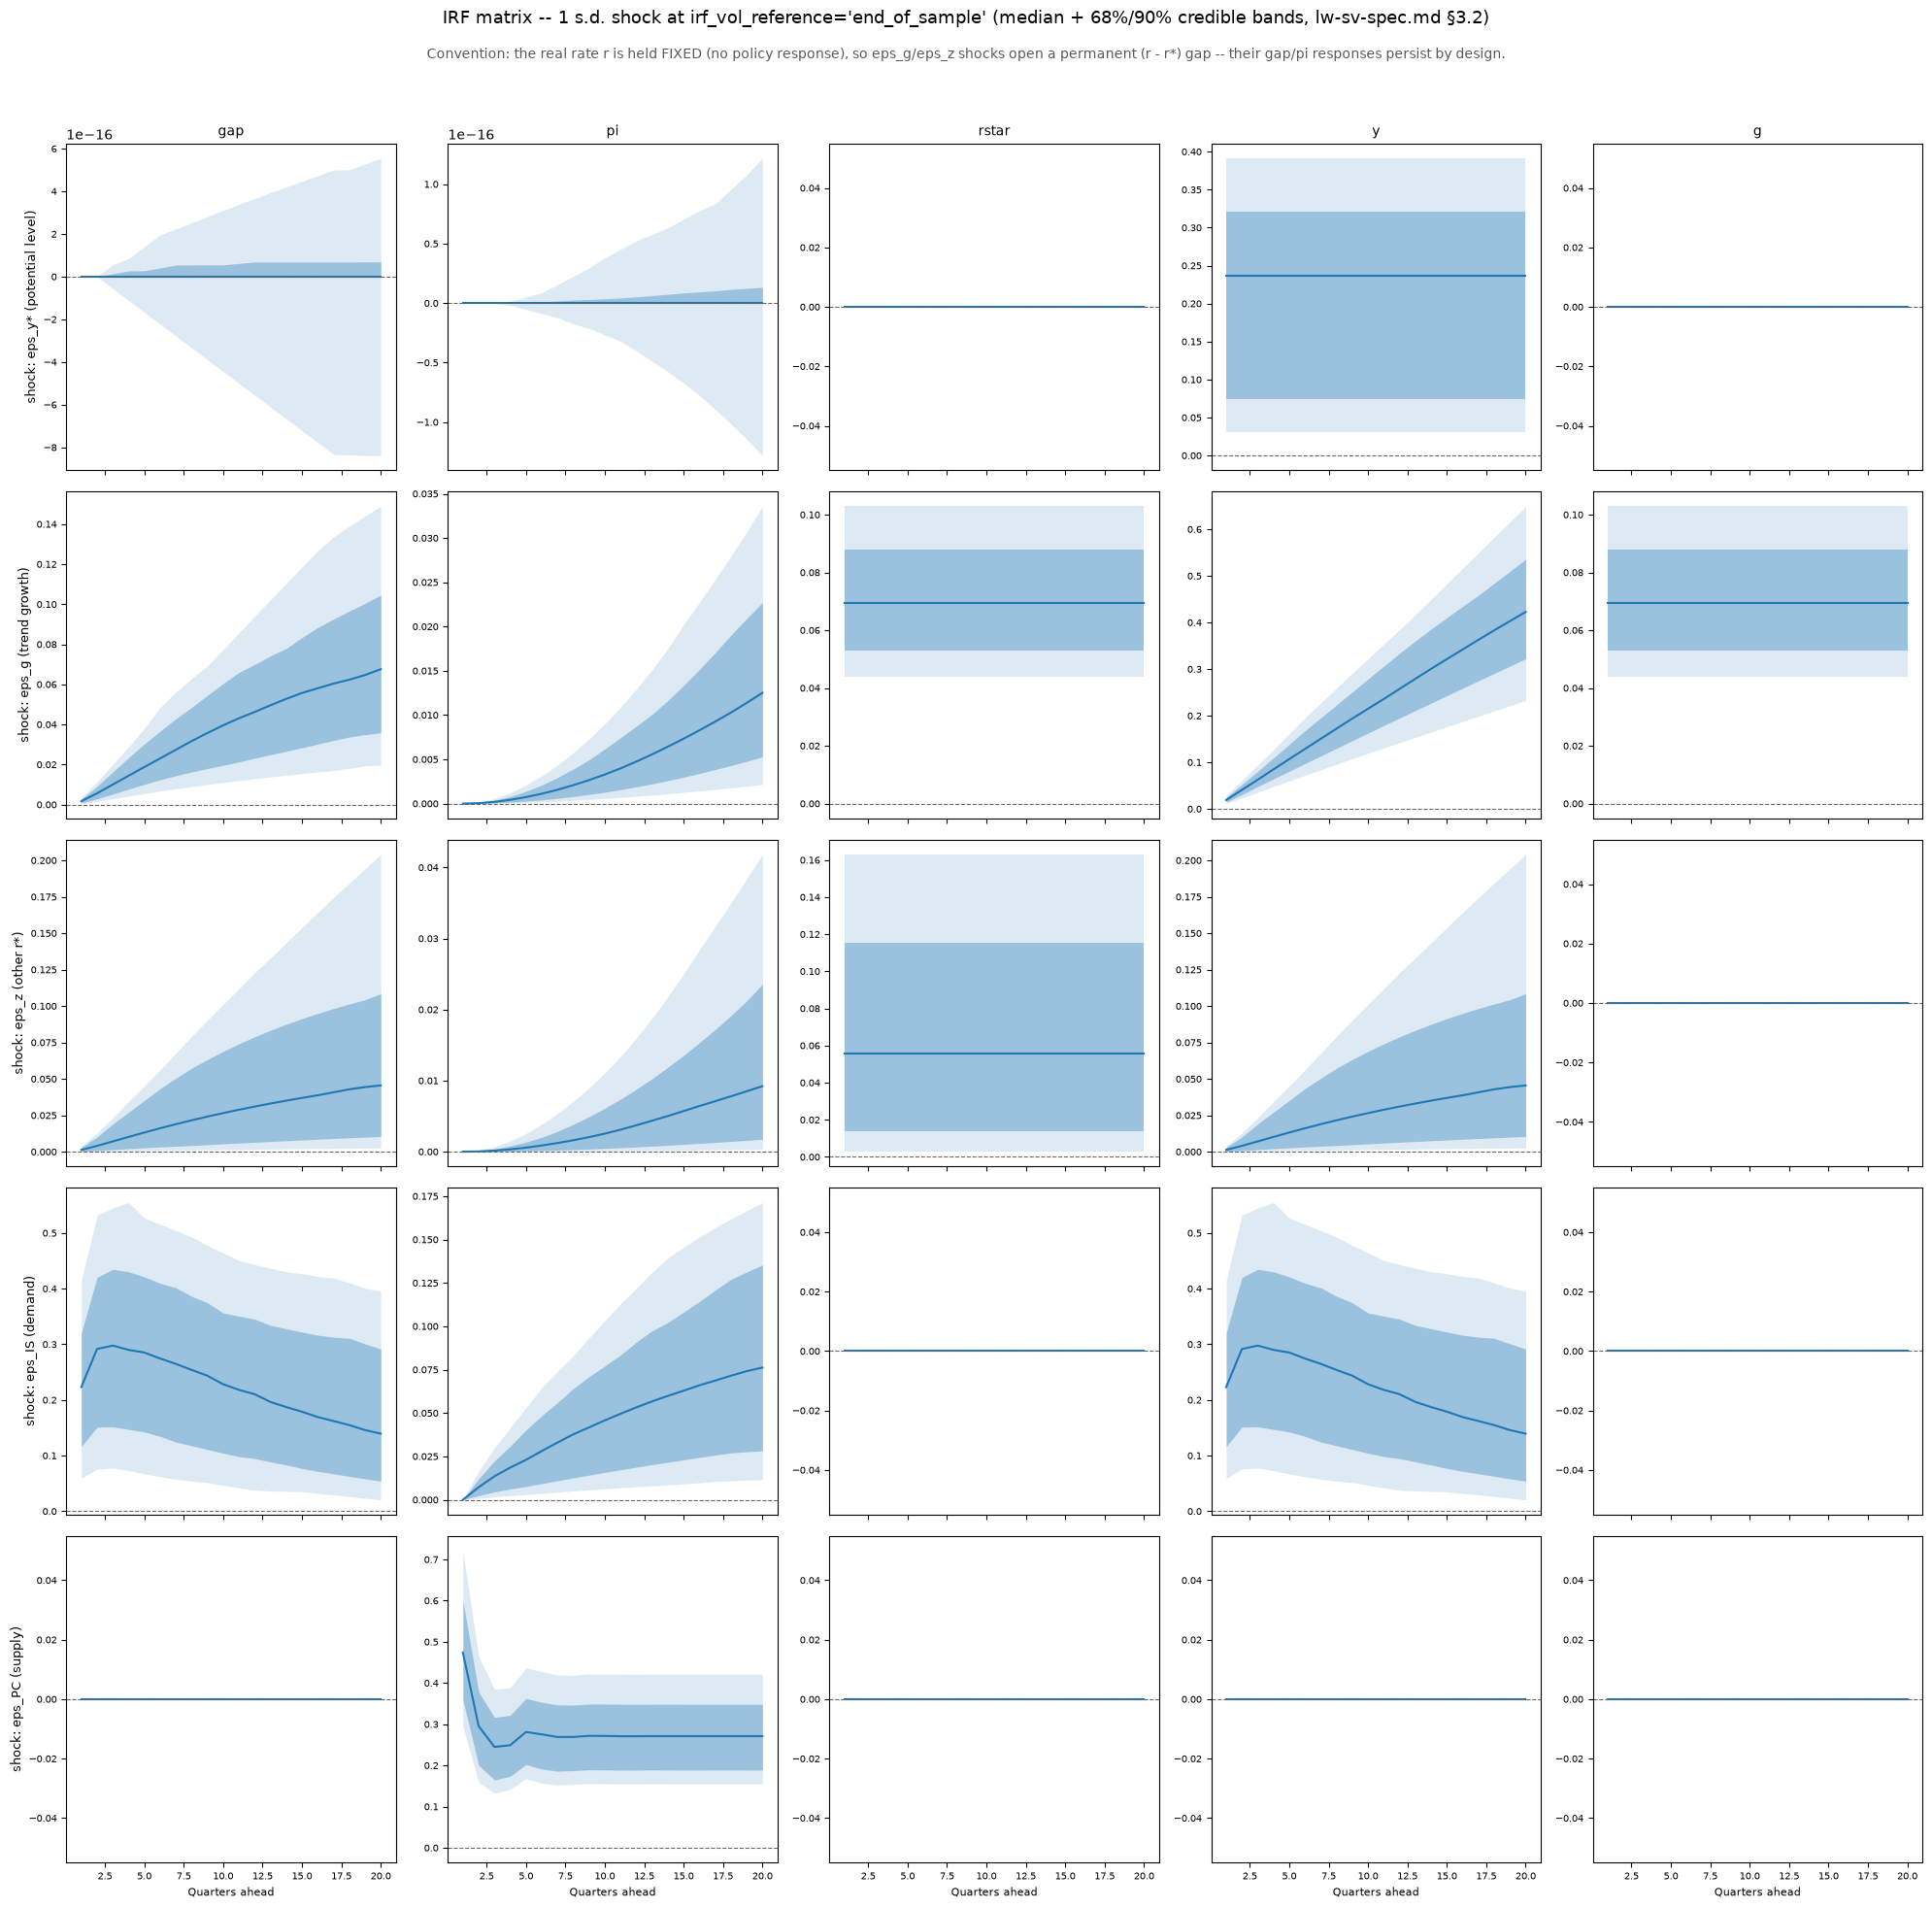

In [8]:
fig = outs.figure("irf")
fig

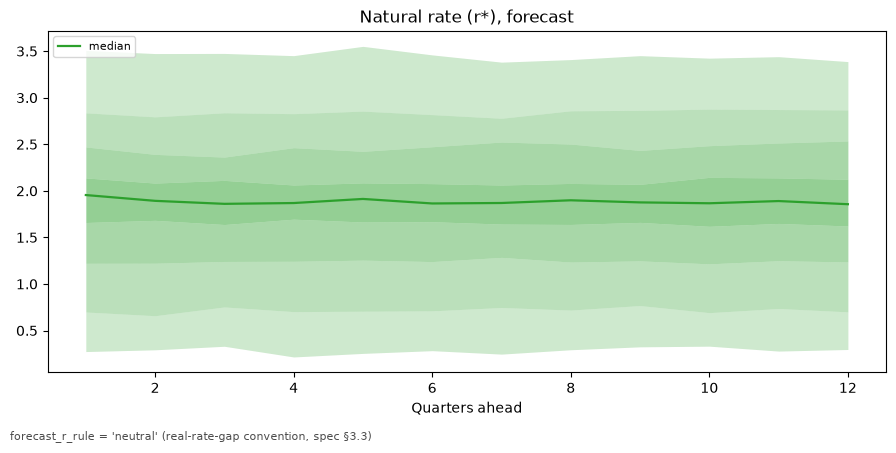

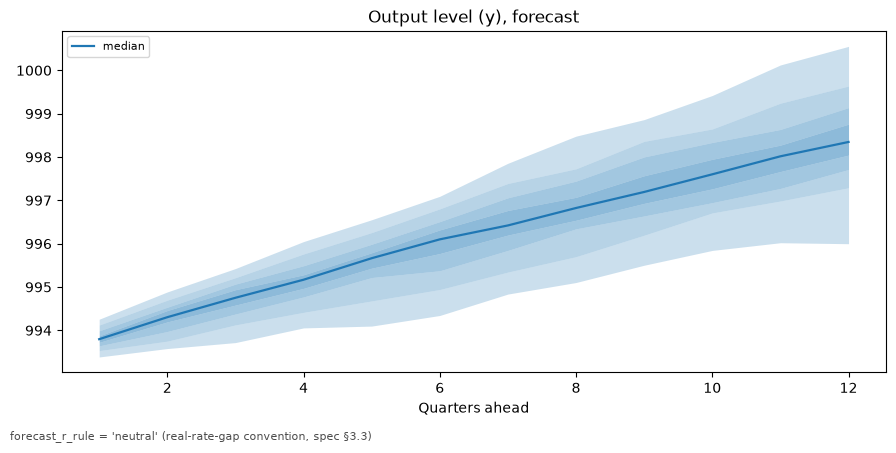

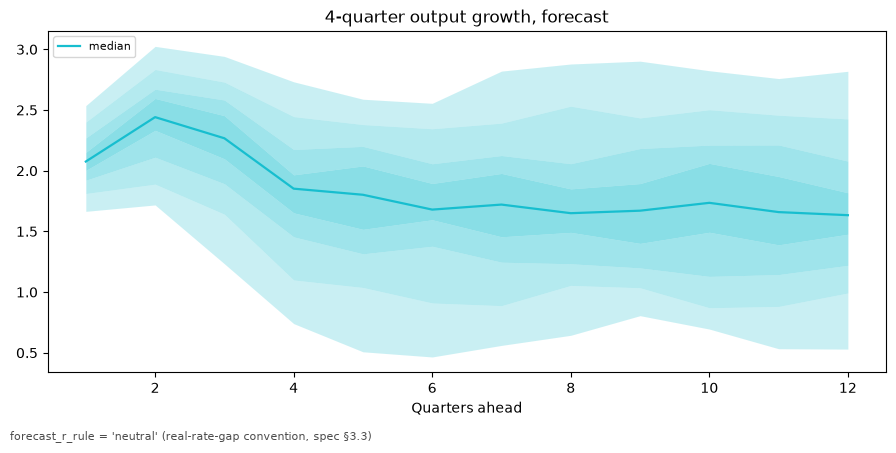

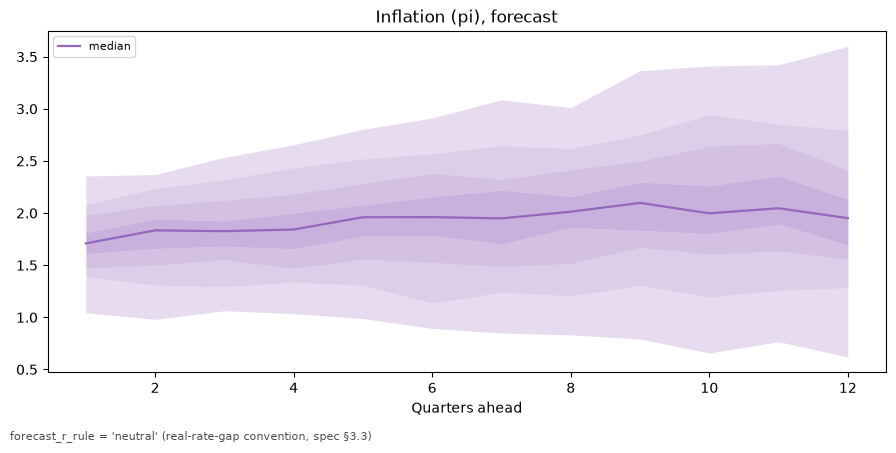

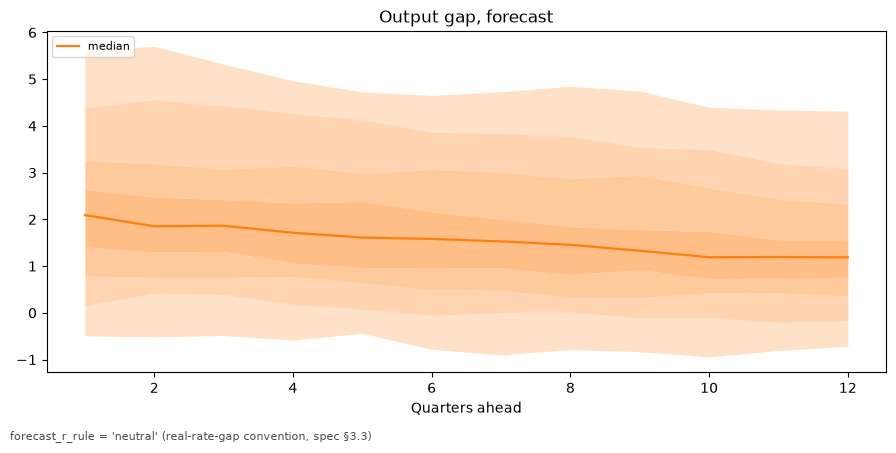

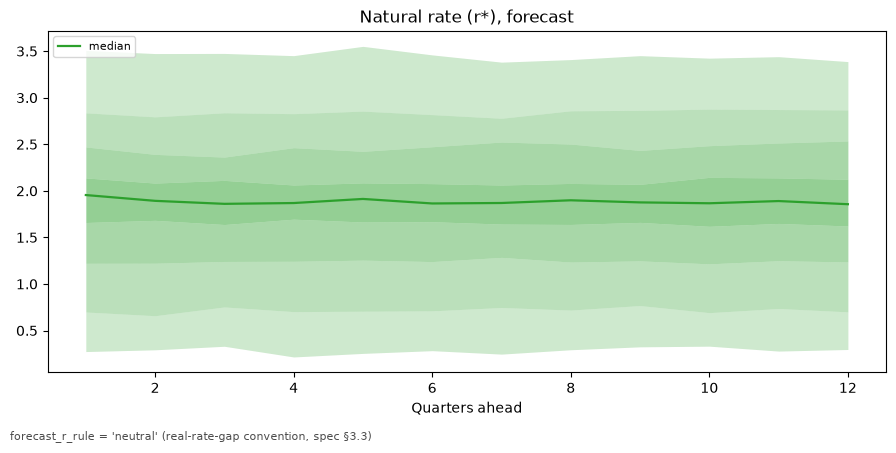

In [9]:
fans = outs.figure("fan")
fans["rstar"]

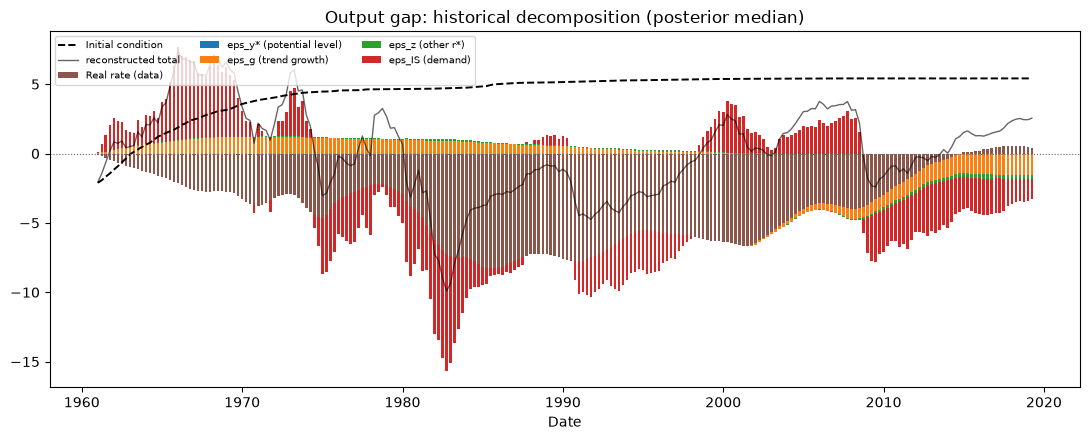

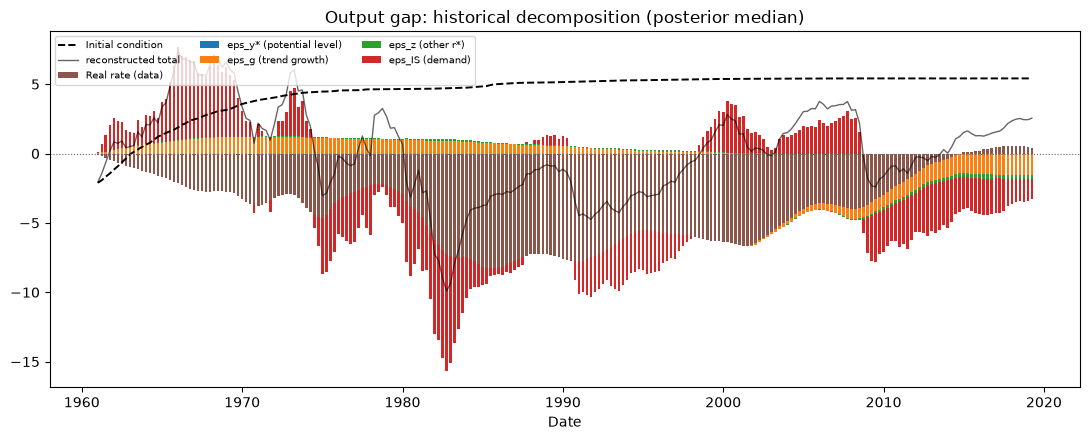

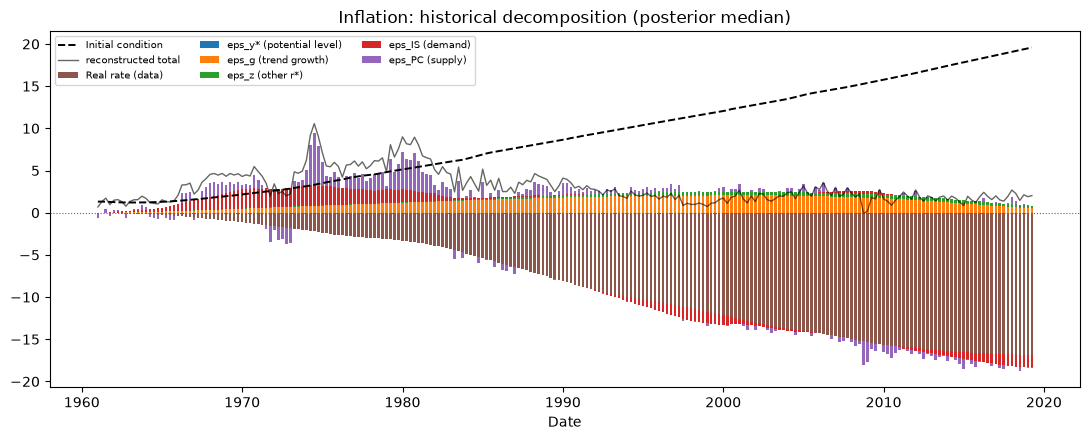

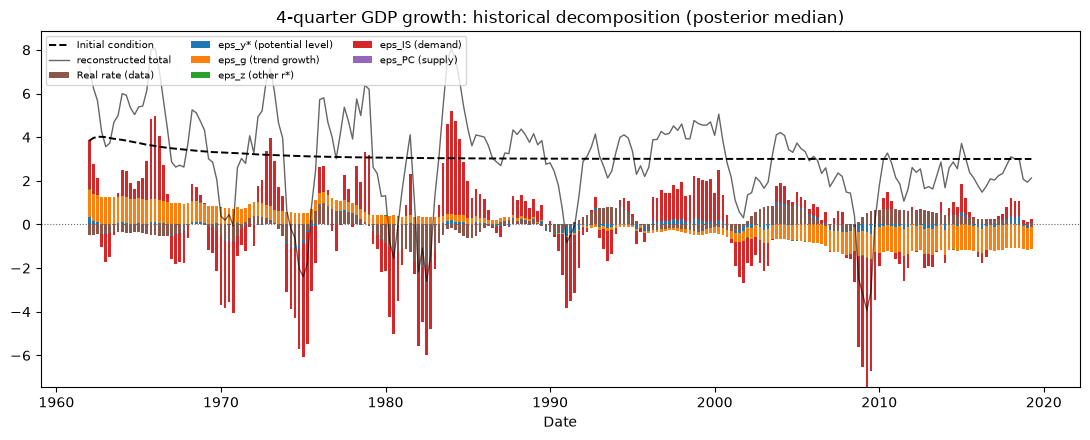

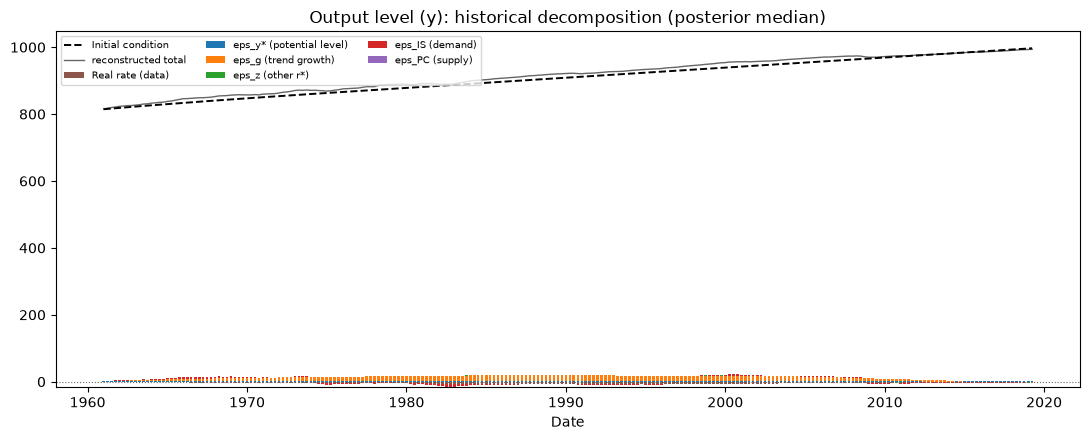

In [10]:
hd = outs.figure("hd")
hd["gap"]

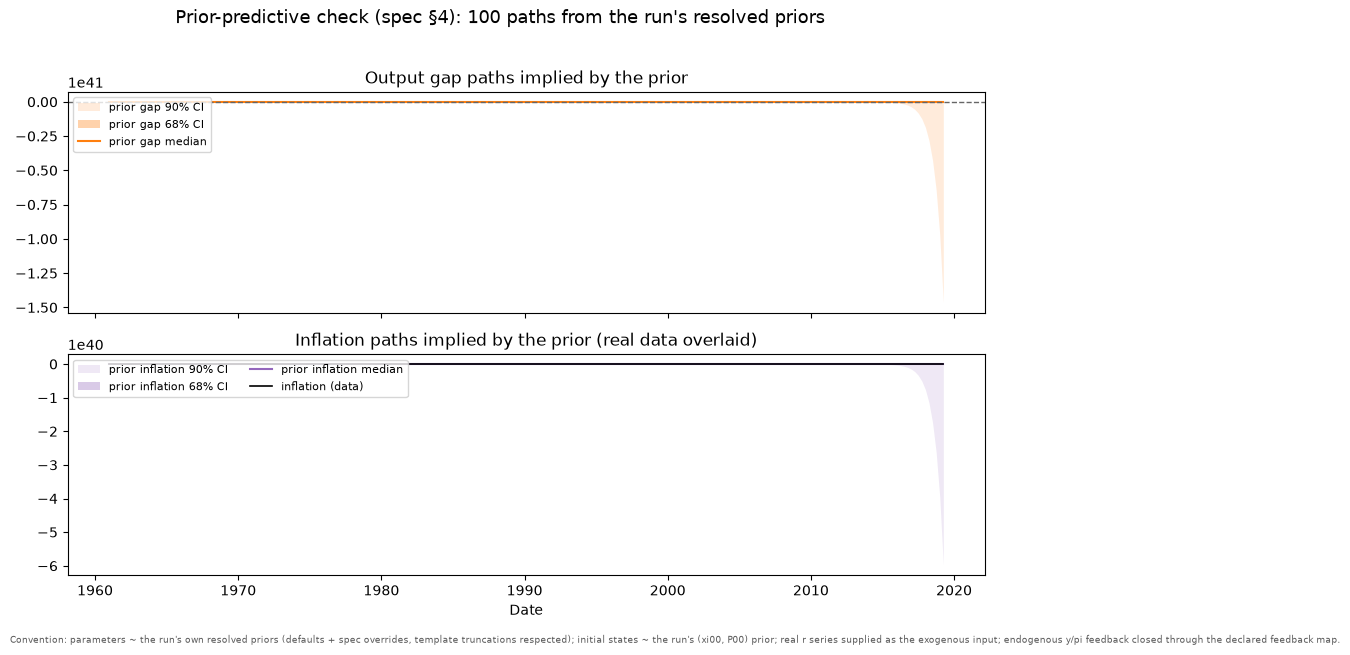

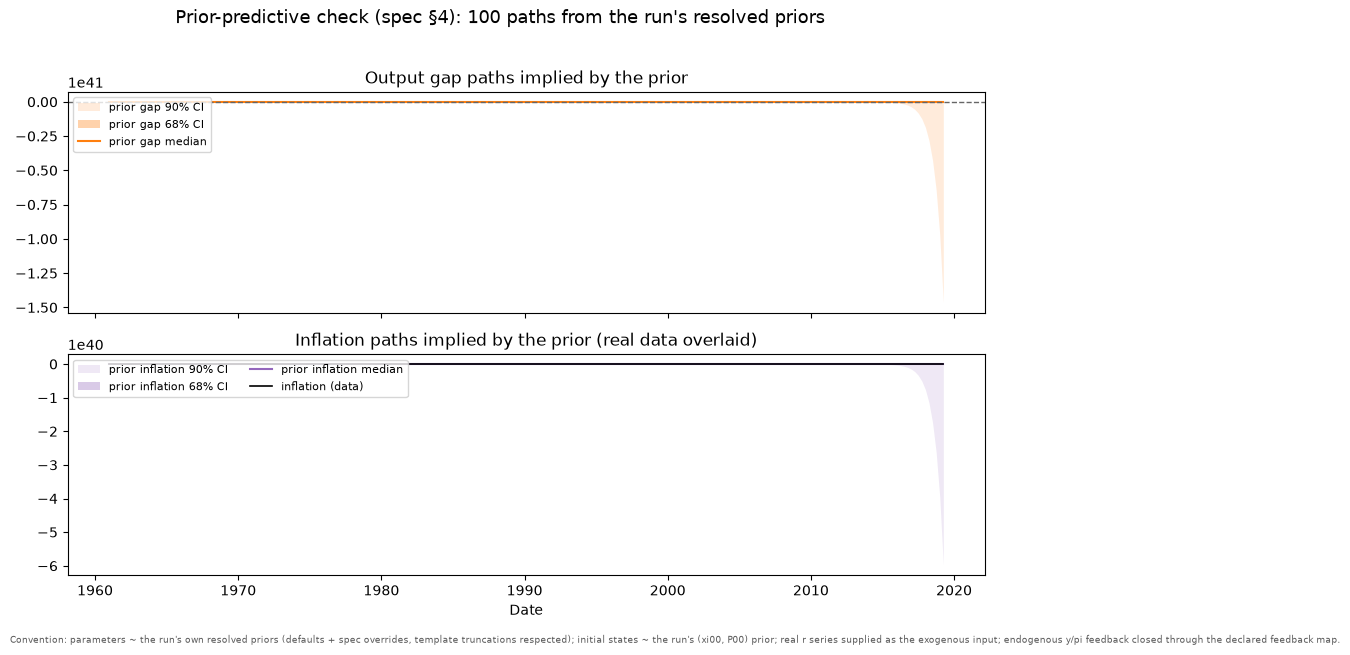

In [11]:
outs.figure("prior_predictive")

Everything the figures show is also available as arrays for your own
plots -- e.g. the posterior-median r* path:

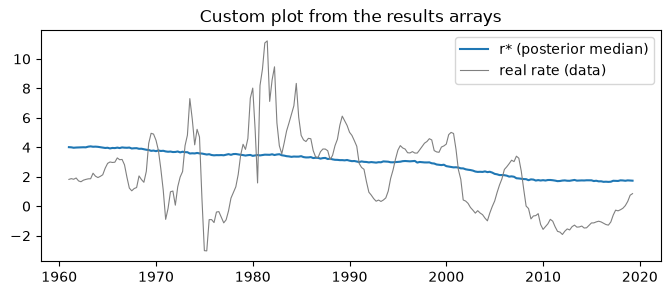

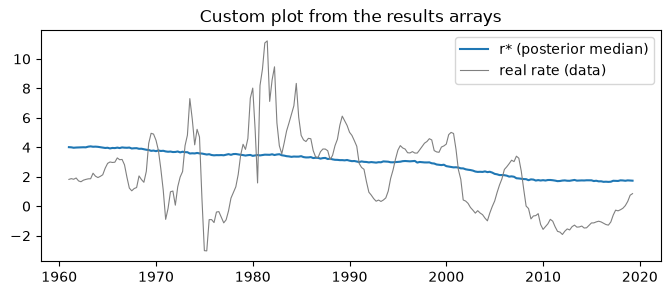

In [12]:
import numpy as np
med = np.median(tcd.rstar, axis=0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tcd.dates, med, label="r* (posterior median)")
ax.plot(tcd.dates, res.r_full[4:], color="0.5", linewidth=0.8, label="real rate (data)")
ax.legend(); ax.set_title("Custom plot from the results arrays")
fig

## 4. The self-contained report is one call

In [13]:
report_path = run.report()
html = report_path.read_text()
print(report_path.name, len(html) // 1024, "KB,", html.count("<img "), "embedded figures")
plt.close("all")

report.html 1321 KB, 12 embedded figures


## 5. Sweeps from Python

`mtk.sweep(...)` runs a prior-override grid as ordinary immutable runs and
returns the comparison programmatically (`result.comparison.table()` is a
long-form DataFrame with posterior summaries and prior-to-posterior
contraction per cell; `result.comparison.headline` the overlaid headline
series), alongside the HTML report. It samples, so it is shown here but not
executed:

```python
result = mtk.sweep(
    {"name": "sigma_g_z", "cells": [
        {"label": "baseline", "priors": {}},
        {"label": "sigma_g_tight", "priors": {"sigma_g": {"sd": 0.015}}},
    ]},
    base_spec=spec, base_dir=REPO / "examples/us_lw_sv",
)
result.comparison.table()
```